In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import pyplot

import os, sys
sys.path.append(os.path.split(os.getcwd())[0]+'/src/')

# import magnus
import magnus.magnus as magnus
import magnus.oscprob.oscprob as oscprob
import magnus.oscprob.oscprobstd as oscprobstd
import magnus.hamiltonians.hamiltonians2nu as hamiltonians2nu
import magnus.hamiltonians.hamiltonians3nu as hamiltonians3nu
import magnus.matter as matter
import magnus.earth as earth
import magnus.globaldefs as gd

# 0. Helper functions and definitions

In [45]:
def prob_label(nu_i, nu_f):
    if (nu_i == gd.NUE):
        if (nu_f == gd.NUE):
            label = r'$P_{\nu_e \to \nu_e}$'
        elif (nu_f == gd.NUMU):
            label = r'$P_{\nu_e \to \nu_\mu}$'
        elif (nu_f == gd.NUTAU):
            label = r'$P_{\nu_e \to \nu_\tau}$'
    elif (nu_i == gd.NUMU):
        if (nu_f == gd.NUE):
            label = r'$P_{\nu_\mu \to \nu_e}$'
        elif (nu_f == gd.NUMU):
            label = r'$P_{\nu_\mu \to \nu_\mu}$'
        elif (nu_f == gd.NUTAU):
            label = r'$P_{\nu_\mu \to \nu_\tau}$'
    elif (nu_i == gd.NUTAU):
        if (nu_f == gd.NUE):
            label = r'$P_{\nu_\tau \to \nu_e}$'
        elif (nu_f == gd.NUMU):
            label = r'$P_{\nu_\tau \to \nu_\mu}$'
        elif (nu_f == gd.NUTAU):
            label = r'$P_{\nu_\tau \to \nu_\tau}$'
    return label

def flavor_index_to_str(nu_l):
    if (nu_l == gd.NUE): return 'e'
    if (nu_l == gd.NUMU): return 'mu'
    if (nu_l == gd.NUTAU): return 'tau'

# Plotting script for probabilities vs. baseline
def make_plot_prob_matt_std_vs_nsi_vs_baseline(nu_i, nu_f, distances, prob_matt_nsi_all, prob_matt_std_all, 
                                               N=3, title=None, save_plot=True):
    
    heights = [1.0]
    widths = [1.0]
    gs_kw = dict(height_ratios=heights, width_ratios=widths)
    fig, ax = plt.subplots(
        ncols=1, 
        nrows=1, 
        gridspec_kw=gs_kw, 
        figsize=[18,9])
    fig.subplots_adjust(hspace=0.05, wspace=0.05)

    prob_matt_std = prob_matt_std_all[:,nu_i,nu_f]
    prob_matt_nsi = prob_matt_nsi_all[:,nu_i,nu_f]

    ax.plot(distances, prob_matt_nsi, lw=1, color='C1', ls='-', label=r'Matter effects with NSI')
    ax.plot(distances, prob_matt_std, lw=1, color='0.2', ls='--', label=r'Standard matter effects')
    
    # Legend
    ax.legend(fontsize=17, frameon=True, loc='center left', handlelength=1.2, handleheight=0.7,
              borderpad=0.8, title_fontsize=20, edgecolor='k', labelspacing=0.7, ncol=1)

    # Annotations
    if (N == 2):
        ax.annotate(r'$\epsilon_{e e} =$ '+str(eps_ee) + ', ' + \
                    r'$\epsilon_{e \mu} =$ '+str(eps_em) + ', ' + \
                    r'$\epsilon_{\mu \mu} =$ '+str(eps_mm),
                    xy = (0.02, 0.03), xycoords='axes fraction', ha='left', fontsize=18)
    elif (N == 3):
        ax.annotate(r'$\epsilon_{e e} =$ '+str(eps_ee) + ', ' + \
                    r'$\epsilon_{e \mu} =$ '+str(eps_em) + ', ' + \
                    r'$\epsilon_{e \tau} =$ '+str(eps_et),
                    xy = (0.02, 0.08), xycoords='axes fraction', ha='left', fontsize=18)
        ax.annotate(r'$\epsilon_{\mu \mu} =$ '+str(eps_mm) + ', ' + \
                    r'$\epsilon_{\mu \tau} =$ '+str(eps_mt) + ', ' + \
                    r'$\epsilon_{\tau \tau} =$ '+str(eps_tt),
                    xy = (0.02, 0.03), xycoords='axes fraction', ha='left', fontsize=18)
        
    # Formatting
    ax.set_ylabel(r'Probability,~'+prob_label(nu_i, nu_f), labelpad=25)
    ax.set_xlim(l_ini, l_fin)
    ax.set_ylim(0, 1)
    ax.set_xscale('log')
    ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=0.10))
    ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=0.02))
    ax.set_xlabel(r'Baseline, $L$ [km]')
    if title is not None:
        ax.set_title(title, fontsize=23, pad=10)
    
    # Save plot
    plt.tight_layout()

    if save_plot:
        filename = 'prob_matt_std_vs_nsi_'+str(N)+'nu_vs_baseline_'+flavor_index_to_str(nu_i)+'_'+flavor_index_to_str(nu_f)+'.'
        plt.savefig('../fig/'+filename+'.pdf', dpi=300)
        plt.savefig('../fig/'+filename+'.jpg', dpi=200)

# Plotting script for probabilities vs. energy
def make_plot_prob_matt_std_vs_nsi_vs_energy(nu_i, nu_f, distances, prob_matt_nsi_all, prob_matt_std_all, 
                                             N=3, title=None, save_plot=True):
    
    heights = [1.0]
    widths = [1.0]
    gs_kw = dict(height_ratios=heights, width_ratios=widths)
    fig, ax = plt.subplots(
        ncols=1, 
        nrows=1, 
        gridspec_kw=gs_kw, 
        figsize=[18,9])
    fig.subplots_adjust(hspace=0.05, wspace=0.05)

    prob_matt_std = prob_matt_std_all[:,nu_i,nu_f]
    prob_matt_nsi = prob_matt_nsi_all[:,nu_i,nu_f]

    ax.plot(energies, prob_matt_nsi, lw=1, color='C1', ls='-', label=r'Matter effects with NSI')
    ax.plot(energies, prob_matt_std, lw=1, color='0.2', ls='--', label=r'Standard matter effects')

    # Legend
    ax.legend(fontsize=17, frameon=True, loc='center right', handlelength=1.2, handleheight=0.7,
                 borderpad=0.8, title_fontsize=20, edgecolor='k', labelspacing=0.7, ncol=1)

    # Annotations
    if (N == 2):
        ax.annotate(r'$\epsilon_{e e} =$ '+str(eps_ee) + ', ' + \
                    r'$\epsilon_{e \mu} =$ '+str(eps_em)  + ', ' + \
                    r'$\epsilon_{\mu \mu} =$ '+str(eps_mm),
                    xy = (0.02, 0.03), xycoords='axes fraction', ha='left', fontsize=18)
    elif (N == 3):
        ax.annotate(r'$\epsilon_{e e} =$ '+str(eps_ee) + ', ' + \
                    r'$\epsilon_{e \mu} =$ '+str(eps_em) + ', ' + \
                    r'$\epsilon_{e \tau} =$ '+str(eps_et),
                    xy = (0.02, 0.08), xycoords='axes fraction', ha='left', fontsize=18)
        ax.annotate(r'$\epsilon_{\mu \mu} =$ '+str(eps_mm) + ', ' + \
                    r'$\epsilon_{\mu \tau} =$ '+str(eps_mt) + ', ' + \
                    r'$\epsilon_{\tau \tau} =$ '+str(eps_tt),
                    xy = (0.02, 0.03), xycoords='axes fraction', ha='left', fontsize=18)
    
    # Formatting
    ax.set_ylabel(r'Probability,~'+prob_label(nu_i, nu_f), labelpad=25)
    ax.set_xlim(energy_min, energy_max)
    ax.set_ylim(0, 1)
    ax.set_xscale('log')
    ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=0.10))
    ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=0.02))
    ax.set_xlabel(r'Neutrino energy, $E_\nu$ [GeV]')
    if title is not None:
        ax.set_title(title, fontsize=23, pad=10)

    # Save plot
    plt.tight_layout()

    if save_plot:
        filename = 'prob_matt_std_vs_nsi_'+str(N)+'nu_vs_energy_'+flavor_index_to_str(nu_i)+'_'+flavor_index_to_str(nu_f)+'.'
        plt.savefig('../fig/'+filename+'.pdf', dpi=300)
        plt.savefig('../fig/'+filename+'.jpg', dpi=200)

# 1. Probabilities with NSI in 2$\nu$: in matter with constant density

## 1.1 Mixing parameters and NSI parameters

In [37]:
# Standard mixing parameters (predefined examples from globaldefs; can change them to anything else)
s12 = gd.S12_NO_BF_NUFIT_6_0 # [adim]
D21 = gd.D21_NO_BF_NUFIT_6_0 # [eV^2]

# NSI parameters (predefined exaples from globaldefs; can change them to anything else)
eps_ee, eps_em, eps_mm = gd.EPS_2

## 1.1 Probabilities vs. distance

Generate probabilities

In [40]:
# Baselines
l_ini, l_fin = 1.e1, 1.e4 # [km]
l_npts = 10000
distances = np.logspace(np.log10(l_ini), np.log10(l_fin), l_npts) # [km]

energy = 2.0*gd.UNIT_GEV # [eV]

# Compute probability vs. baseline
# For the 2nu case, osc_prob returns a 3x3 NumPy array with the probabilities: [[Pee, Pem], [Pme, Pmm]]

# Matter potential
rho = 3.0 # Matter density [g cm^{-3}]
num_density_e = matter.num_density_e_func(l=0.0, density_matter_func=lambda l: rho, electron_fraction=0.5) # Electron number density [eV^3]
VCC = matter.VCC_func(l=0.0, num_density_e_func=lambda l: num_density_e) # Coherent forward potential, VCC [eV]

# Vacuum Hamiltonian
H_vac = hamiltonians2nu.hamiltonian_2nu_vacuum(energy, s12, D21)

# Standard matter Hamiltonian
H_matt = hamiltonians2nu.hamiltonian_2nu_matter(VCC)

# NSI matter Hamiltonian
H_nsi = hamiltonians2nu.hamiltonian_2nu_nsi(VCC, [eps_ee, eps_em, eps_mm])

# Probabilities
prob_matt_std_all = np.array([oscprob.osc_prob(lambda r: H_vac-H_matt, 0.0, l*gd.CONV_KM_TO_INV_EV, n_slabs=1, n_tpts_per_slab=2, 
                                               magnus_exp_order=1, integration_method='simpson', n_jobs=1) for l in distances])
prob_matt_nsi_all = np.array([oscprob.osc_prob(lambda r: H_vac-H_matt-H_nsi, 0.0, l*gd.CONV_KM_TO_INV_EV, n_slabs=1, n_tpts_per_slab=2, 
                                               magnus_exp_order=1, integration_method='simpson', n_jobs=1) for l in distances])


Plot probabilities

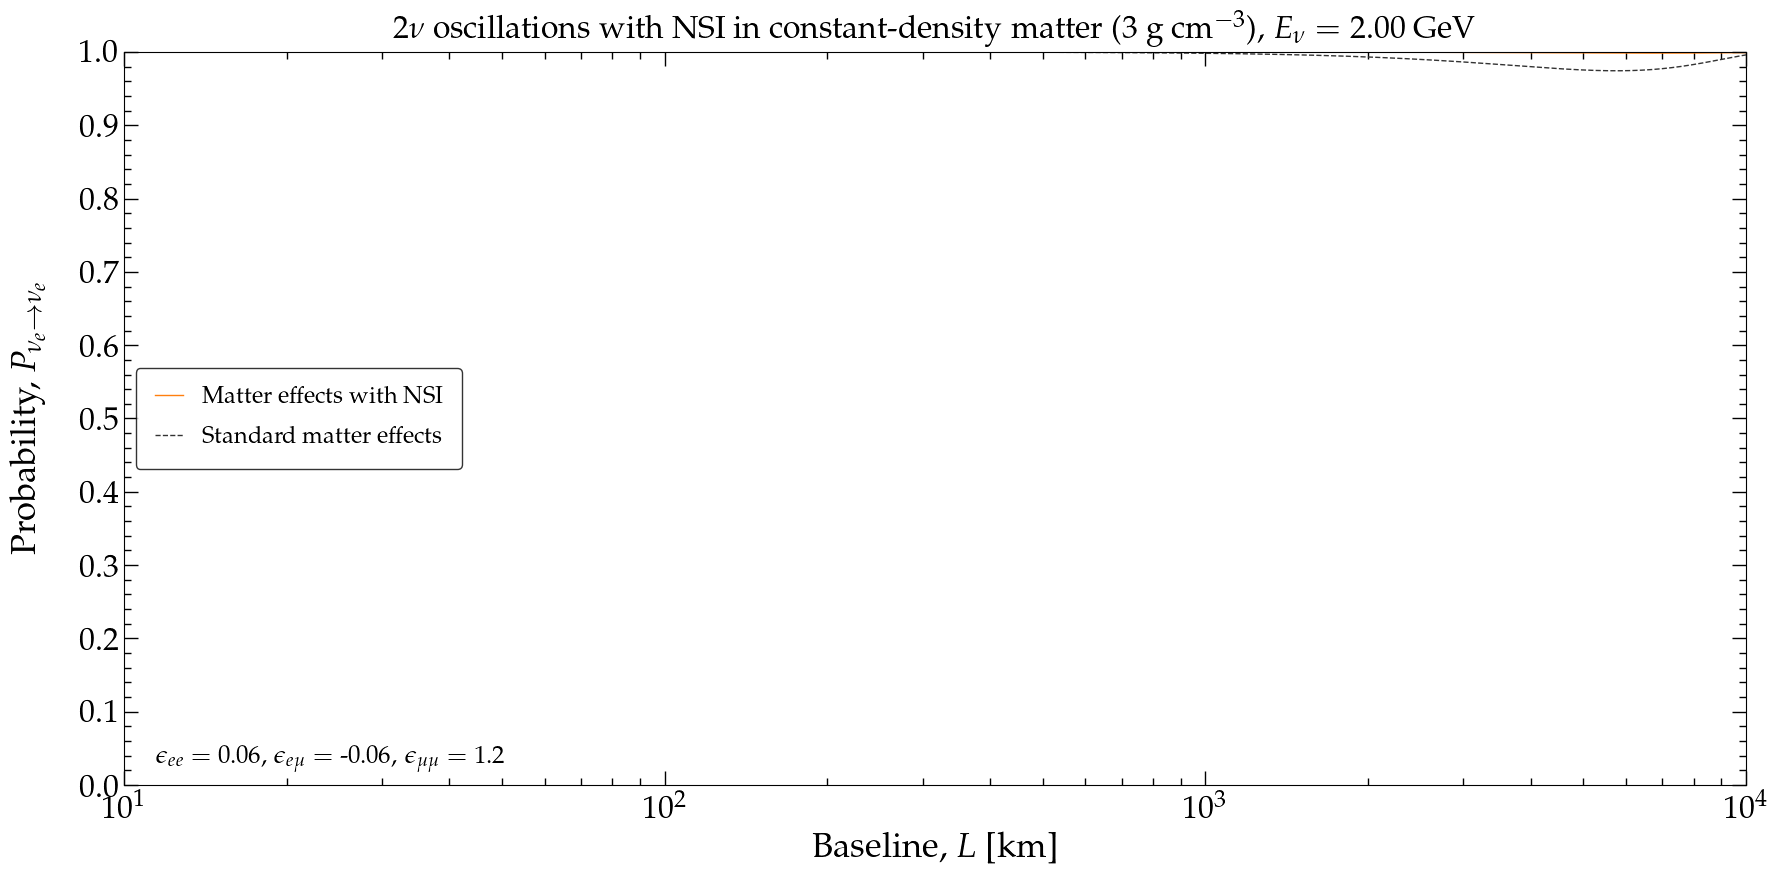

In [46]:
make_plot_prob_matt_std_vs_nsi_vs_baseline(gd.NUE, gd.NUE, distances, prob_matt_nsi_all, prob_matt_std_all, N=2,
                                           title=r'$2\nu$ oscillations with NSI in constant-density matter (3~g~cm$^{-3}$), ' + \
                                                   r'$E_\nu = $~{:.2f}~GeV'.format(energy/gd.UNIT_GEV),
                                           save_plot=False)

## 2.3 Probabilities vs. energy

In [48]:
# Energies
energy_min, energy_max = 1.e-1, 1.e1 # [GeV]
energy_npts = 5000
energies = np.logspace(np.log10(energy_min), np.log10(energy_max), energy_npts) # [GeV]

baseline = 5.e3 # [km]

# Matter potential
rho = 3.0 # Matter density [g cm^{-3}]
num_density_e = matter.num_density_e_func(l=0.0, density_matter_func=lambda l: rho, electron_fraction=0.5) # Electron number density [eV^3]
VCC = matter.VCC_func(l=0.0, num_density_e_func=lambda l: num_density_e) # Coherent forward potential, VCC [eV]

# Vacuum Hamiltonian without the 1/E prefactos
H_vac_en_indep = hamiltonians2nu.hamiltonian_2nu_vacuum_energy_independent(s12, D21)

# Standard matter Hamiltonian
H_matt = hamiltonians2nu.hamiltonian_2nu_matter(VCC)

# NSI matter Hamiltonian
H_nsi = hamiltonians2nu.hamiltonian_2nu_nsi(VCC, [eps_ee, eps_em, eps_mm])

# Total Hamiltonian, standard matter effects
def H_matt_std(energy, l):
    return (1/energy)*H_vac_en_indep - H_matt
prob_matt_std_all = np.array([oscprob.osc_prob(lambda l: H_matt_std(enu*gd.UNIT_GEV, l), 
                                               0.0, gd.CONV_KM_TO_INV_EV*baseline, 
                                               n_slabs=1, n_tpts_per_slab=10, magnus_exp_order=1) for enu in energies])

# Total Hamiltonian, NSI matter effects
def H_matt_nsi(energy, l):
    return (1/energy)*H_vac_en_indep - H_matt - H_nsi
prob_matt_nsi_all = np.array([oscprob.osc_prob(lambda l: H_matt_nsi(enu*gd.UNIT_GEV, l), 
                                               0.0, gd.CONV_KM_TO_INV_EV*baseline, 
                                               n_slabs=1, n_tpts_per_slab=10, magnus_exp_order=1) for enu in energies])

Plot probabilities

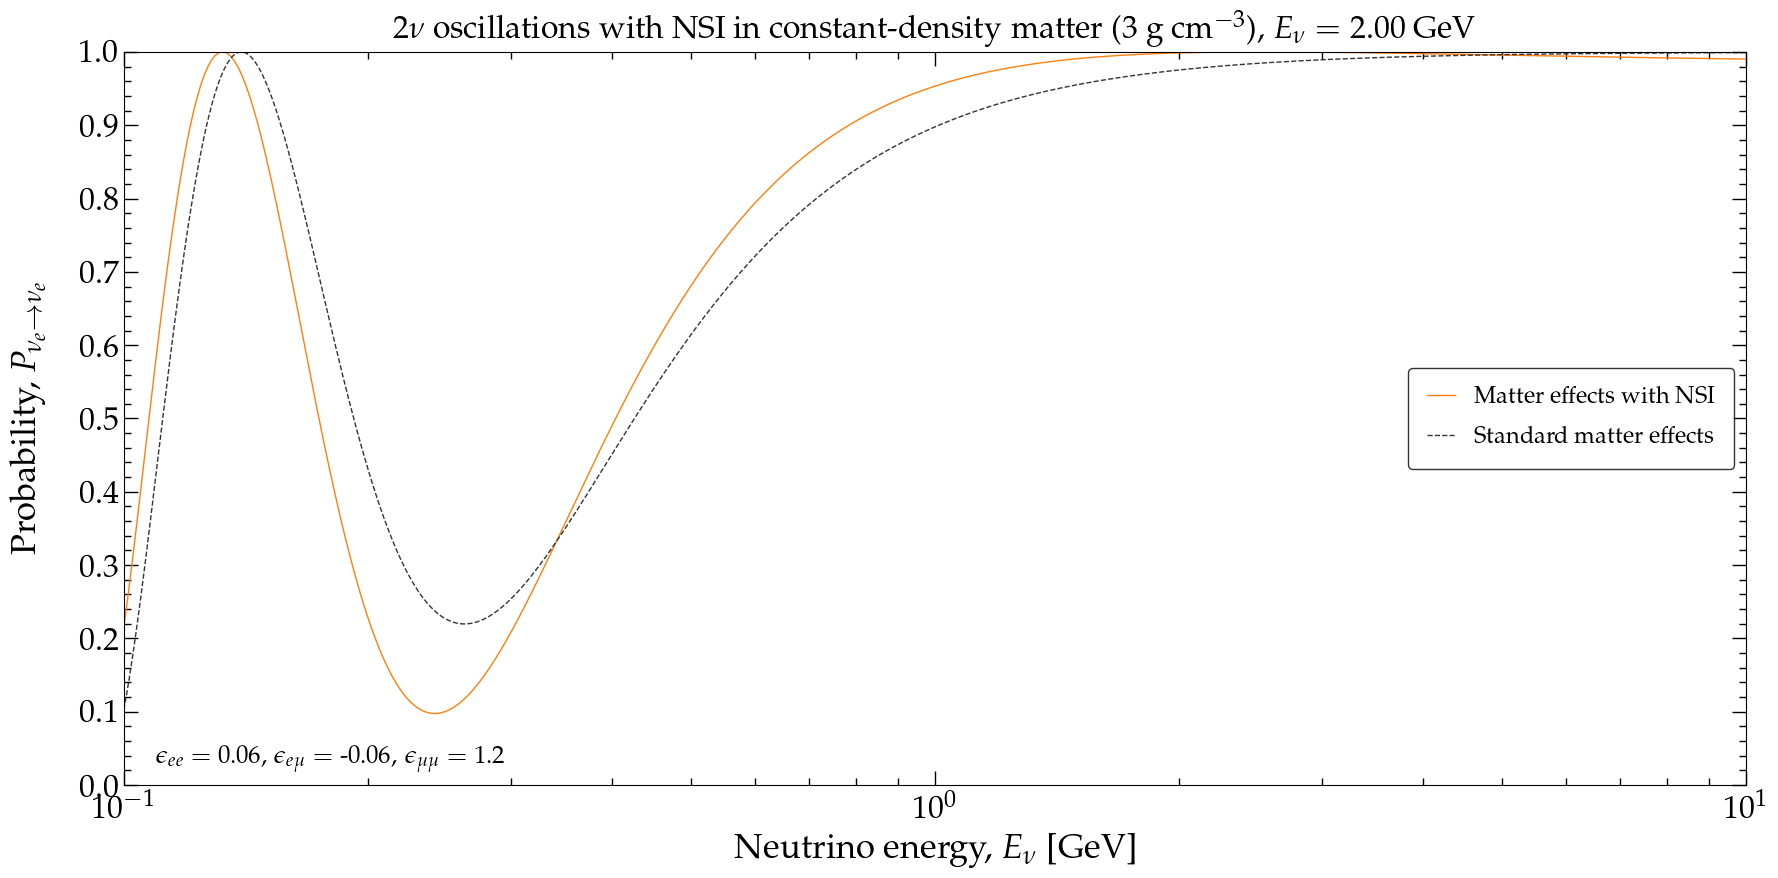

In [49]:
make_plot_prob_matt_std_vs_nsi_vs_energy(gd.NUE, gd.NUE, energies, prob_matt_nsi_all, prob_matt_std_all, N=2,
                                         title=r'$2\nu$ oscillations with NSI in constant-density matter (3~g~cm$^{-3}$), ' + \
                                               r'$E_\nu = $~{:.2f}~GeV'.format(energy/gd.UNIT_GEV),
                                         save_plot=False)

# 2. Probabilities with NSI in 3$\nu$: in matter with constant density

## 2.1 Mixing parameters and NSI parameters

In [3]:
# Standard mixing parameters (predefined examples from globaldefs; can change them to anything else)
s12 = gd.S12_NO_BF_NUFIT_6_0 # [adim]
s23 = gd.S23_NO_BF_NUFIT_6_0 # [adim]
s13 = gd.S13_NO_BF_NUFIT_6_0 # [adim]
dCP = gd.DCP_NO_BF_NUFIT_6_0 # [adim]
D21 = gd.D21_NO_BF_NUFIT_6_0 # [eV^2]
D31 = gd.D31_NO_BF_NUFIT_6_0 # [eV^2]

# NSI parameters (predefined exaples from globaldefs; can change them to anything else)
eps_ee, eps_em, eps_et, eps_mm, eps_mt, eps_tt = gd.EPS_3

## 2.2 Probabilities vs. distance

Generate probabilities

In [4]:
# Baselines
l_ini, l_fin = 1.e1, 1.e4 # [km]
l_npts = 10000
distances = np.logspace(np.log10(l_ini), np.log10(l_fin), l_npts) # [km]

energy = 2.0*gd.UNIT_GEV # [eV]

# Compute probability vs. baseline
# For the 3nu case, osc_prob returns a 3x3 NumPy array with the probabilities: [[Pee, Pem, Pet], [Pme, Pmm, Pmt], [Pte, Ptm, Ptt]]

# Matter potential
rho = 3.0 # Matter density [g cm^{-3}]
num_density_e = matter.num_density_e_func(l=0.0, density_matter_func=lambda l: rho, electron_fraction=0.5) # Electron number density [eV^3]
VCC = matter.VCC_func(l=0.0, num_density_e_func=lambda l: num_density_e) # Coherent forward potential, VCC [eV]

# Vacuum Hamiltonian
H_vac = hamiltonians3nu.hamiltonian_3nu_vacuum(energy, s12, s23, s13, dCP, D21, D31)

# Standard matter Hamiltonian
H_matt = hamiltonians3nu.hamiltonian_3nu_matter(VCC)

# NSI matter Hamiltonian
H_nsi = hamiltonians3nu.hamiltonian_3nu_nsi(VCC, [eps_ee, eps_em, eps_et, eps_mm, eps_mt, eps_tt])

# Probabilities
prob_matt_std_all = np.array([oscprob.osc_prob(lambda r: H_vac-H_matt, 0.0, l*gd.CONV_KM_TO_INV_EV, n_slabs=1, n_tpts_per_slab=2, 
                                               magnus_exp_order=1, integration_method='simpson', n_jobs=1) for l in distances])
prob_matt_nsi_all = np.array([oscprob.osc_prob(lambda r: H_vac-H_matt-H_nsi, 0.0, l*gd.CONV_KM_TO_INV_EV, n_slabs=1, n_tpts_per_slab=2, 
                                               magnus_exp_order=1, integration_method='simpson', n_jobs=1) for l in distances])


Plot probabilities

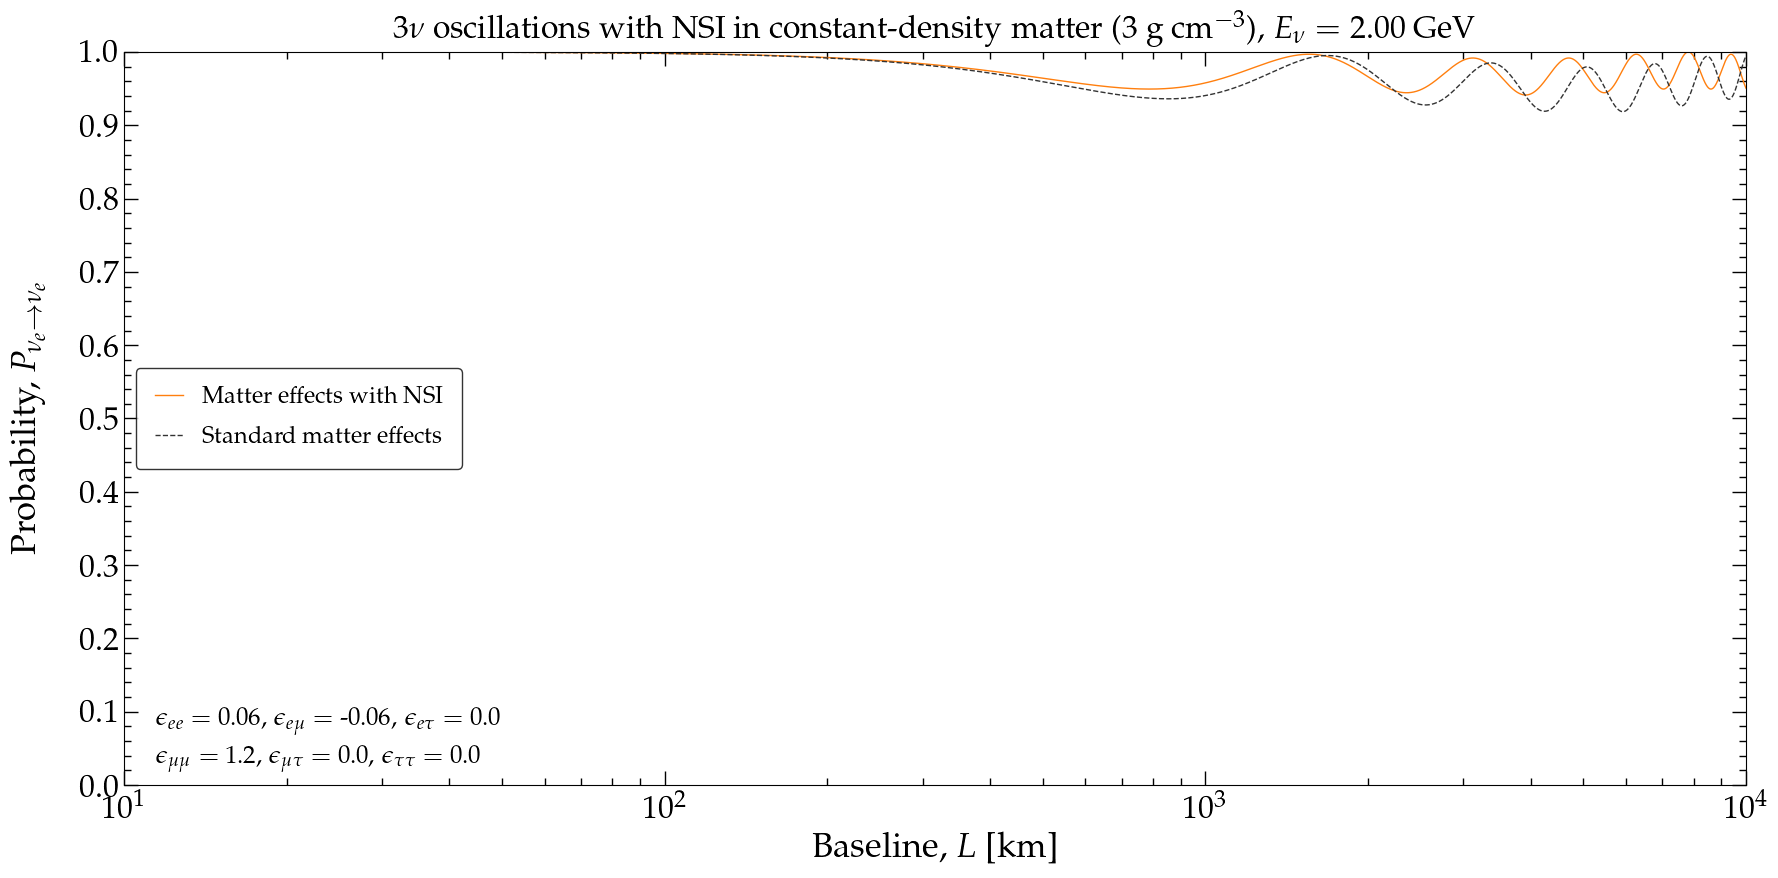

In [19]:
make_plot_prob_matt_std_vs_nsi_vs_baseline(gd.NUE, gd.NUE, distances, prob_matt_nsi_all, prob_matt_std_all, N=3,
                                           title=r'$3\nu$ oscillations with NSI in constant-density matter (3~g~cm$^{-3}$), ' + \
                                                   r'$E_\nu = $~{:.2f}~GeV'.format(energy/gd.UNIT_GEV),
                                           save_plot=False)

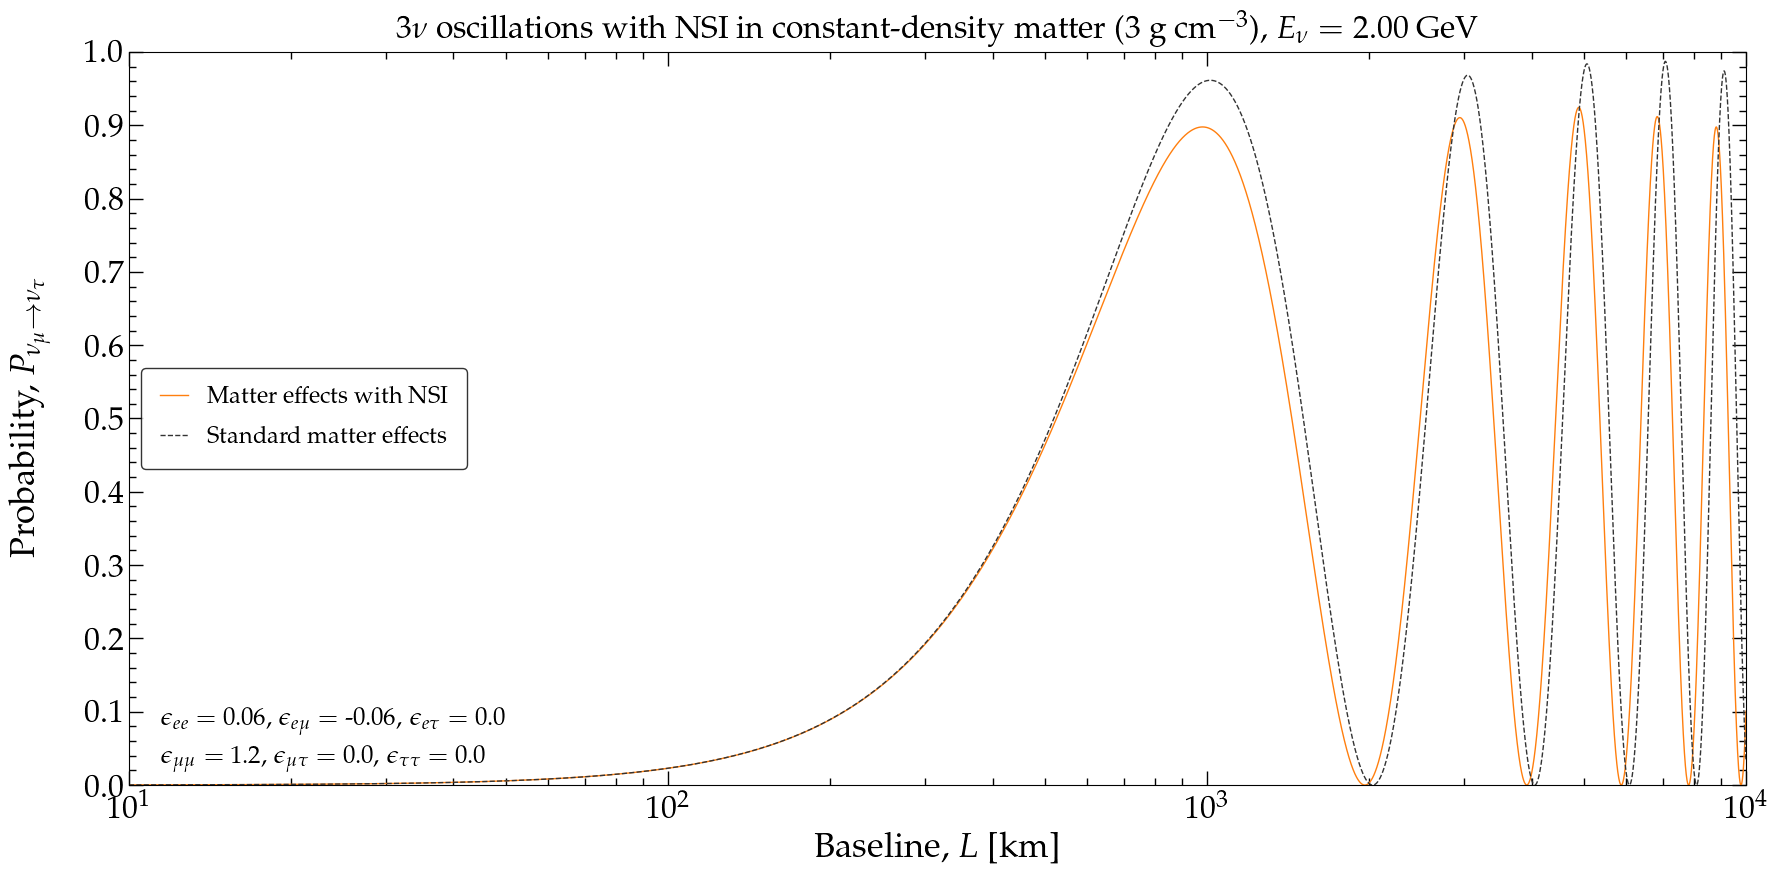

In [20]:
make_plot_prob_matt_std_vs_nsi_vs_baseline(gd.NUMU, gd.NUTAU, distances, prob_matt_nsi_all, prob_matt_std_all, N=3,
                                           title=r'$3\nu$ oscillations with NSI in constant-density matter (3~g~cm$^{-3}$), ' + \
                                                   r'$E_\nu = $~{:.2f}~GeV'.format(energy/gd.UNIT_GEV),
                                           save_plot=False)

## 2.3 Probabilities vs. energy

Generate probabilities

In [22]:
# Energies
energy_min, energy_max = 1.e-1, 1.e1 # [GeV]
energy_npts = 5000
energies = np.logspace(np.log10(energy_min), np.log10(energy_max), energy_npts) # [GeV]

baseline = 5.e3 # [km]

# Matter potential
rho = 3.0 # Matter density [g cm^{-3}]
num_density_e = matter.num_density_e_func(l=0.0, density_matter_func=lambda l: rho, electron_fraction=0.5) # Electron number density [eV^3]
VCC = matter.VCC_func(l=0.0, num_density_e_func=lambda l: num_density_e) # Coherent forward potential, VCC [eV]

# Vacuum Hamiltonian without the 1/E prefactos
H_vac_en_indep = hamiltonians3nu.hamiltonian_3nu_vacuum_energy_independent(s12, s23, s13, dCP, D21, D31)

# Standard matter Hamiltonian
H_matt = hamiltonians3nu.hamiltonian_3nu_matter(VCC)

# NSI matter Hamiltonian
H_nsi = hamiltonians3nu.hamiltonian_3nu_nsi(VCC, [eps_ee, eps_em, eps_et, eps_mm, eps_mt, eps_tt])

# Total Hamiltonian, standard matter effects
def H_matt_std(energy, l):
    return (1/energy)*H_vac_en_indep - H_matt
prob_matt_std_all = np.array([oscprob.osc_prob(lambda l: H_matt_std(enu*gd.UNIT_GEV, l), 
                                               0.0, gd.CONV_KM_TO_INV_EV*baseline, 
                                               n_slabs=1, n_tpts_per_slab=10, magnus_exp_order=1) for enu in energies])

# Total Hamiltonian, NSI matter effects
def H_matt_nsi(energy, l):
    return (1/energy)*H_vac_en_indep - H_matt - H_nsi
prob_matt_nsi_all = np.array([oscprob.osc_prob(lambda l: H_matt_nsi(enu*gd.UNIT_GEV, l), 
                                               0.0, gd.CONV_KM_TO_INV_EV*baseline, 
                                               n_slabs=1, n_tpts_per_slab=10, magnus_exp_order=1) for enu in energies])

Plot probabilities

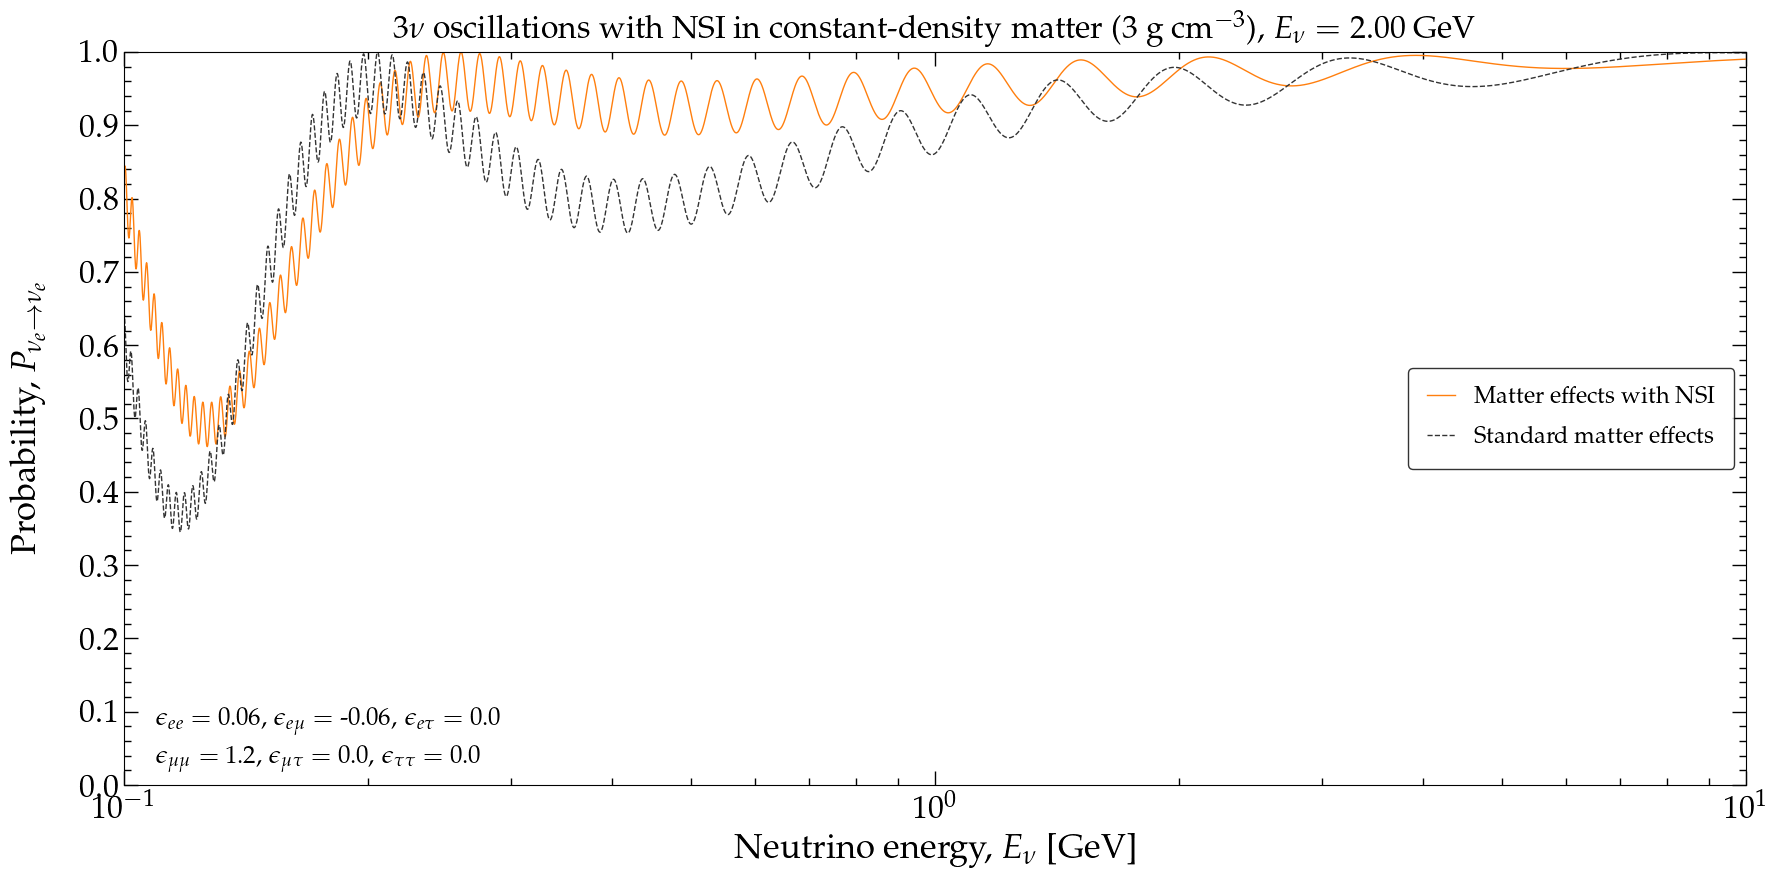

In [34]:
make_plot_prob_matt_std_vs_nsi_vs_energy(gd.NUE, gd.NUE, energies, prob_matt_nsi_all, prob_matt_std_all, N=3,
                                         title=r'$3\nu$ oscillations with NSI in constant-density matter (3~g~cm$^{-3}$), ' + \
                                               r'$E_\nu = $~{:.2f}~GeV'.format(energy/gd.UNIT_GEV),
                                         save_plot=False)

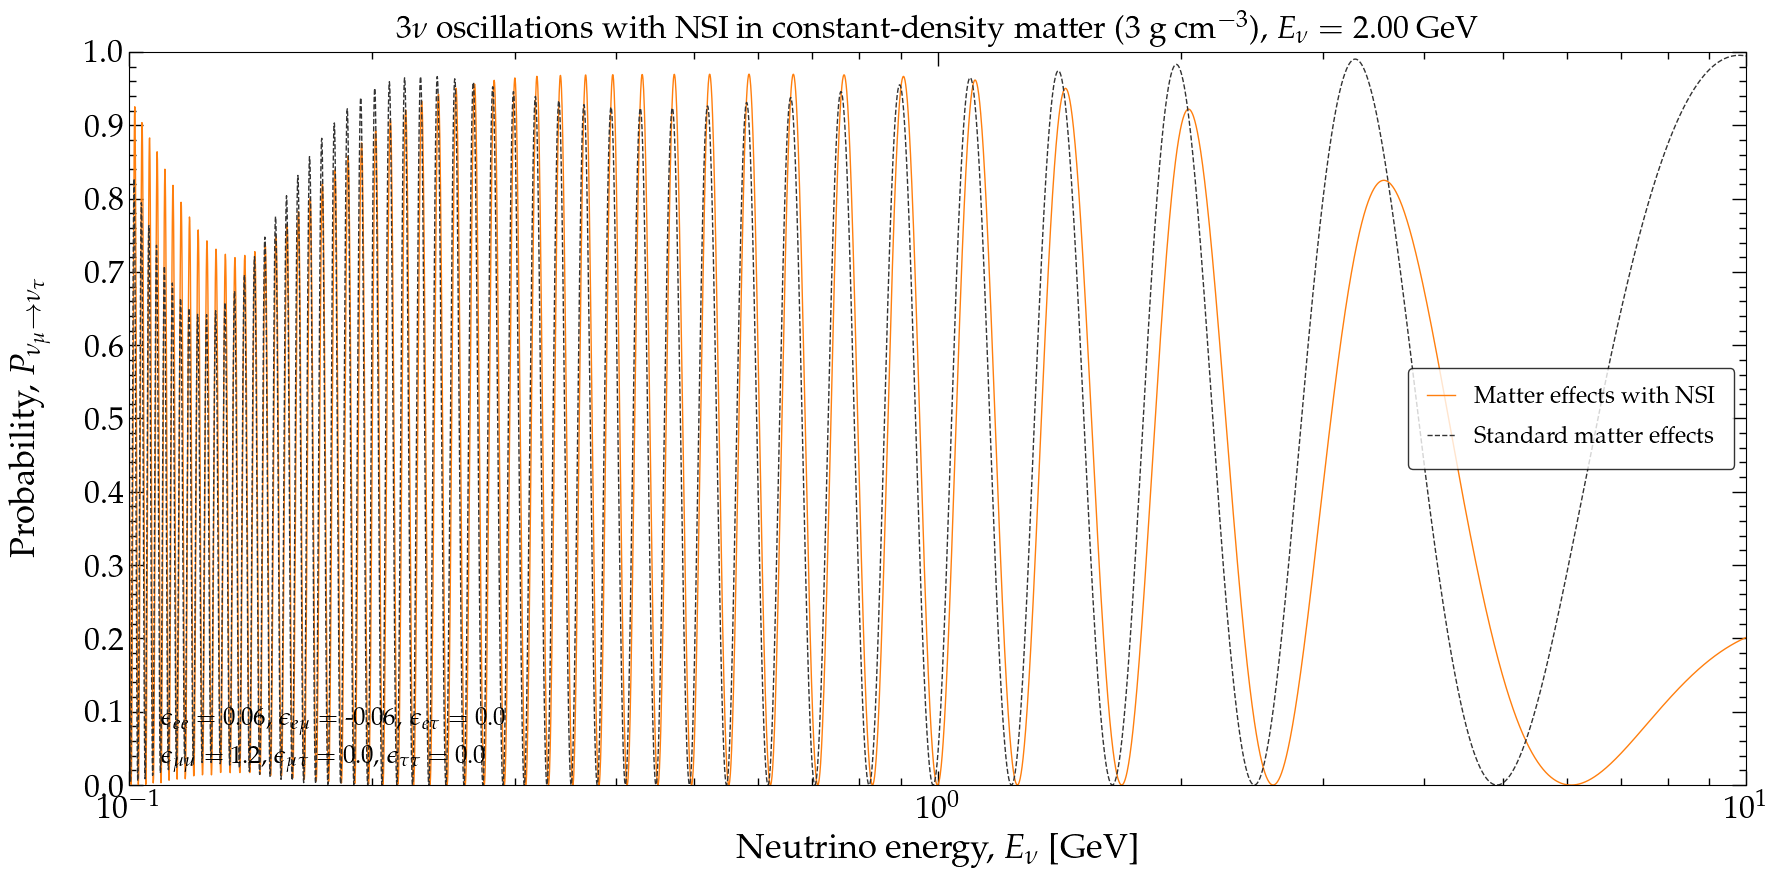

In [39]:
make_plot_prob_matt_std_vs_nsi_vs_energy(gd.NUMU, gd.NUTAU, energies, prob_matt_nsi_all, prob_matt_std_all, N=3,
                                         title=r'$3\nu$ oscillations with NSI in constant-density matter (3~g~cm$^{-3}$), ' + \
                                               r'$E_\nu = $~{:.2f}~GeV'.format(energy/gd.UNIT_GEV),
                                         save_plot=False)